# 🛒 Customer Intelligence System
## Phase 1: Exploratory Data Analysis (EDA)

**Dataset:** E-commerce User Behavioral Dataset  
**Rows:** ~1,000,000 | **Columns:** 45  
**Goal:** Understand distributions, correlations, outliers & behavioral patterns

---
### Notebook Sections
1. Setup & Data Loading
2. Dataset Overview
3. Missing Values & Data Quality
4. Univariate Analysis
5. Bivariate Analysis
6. Correlation Analysis
7. Behavioral Pattern Analysis
8. Wellbeing vs Shopping Analysis
9. Key Insights Summary

## 1. Setup & Data Loading

In [1]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
COLORS = sns.color_palette('muted', 10)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [3]:
# Load dataset
# For large files, we sample for speed during EDA
FILE_PATH = 'e_commerce_shopper_behaviour_and_lifestyle.csv'  #
SAMPLE_SIZE = None  

df_full = pd.read_csv(FILE_PATH)
df = df_full.sample(n=SAMPLE_SIZE, random_state=42) if SAMPLE_SIZE else df_full

print(f'Full dataset shape : {df_full.shape}')
print(f'Working sample size: {df.shape}')

Full dataset shape : (1000000, 60)
Working sample size: (1000000, 60)


## 2. Dataset Overview

In [4]:
print('=== FIRST 5 ROWS ===')
df.head()

=== FIRST 5 ROWS ===


,user_id,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,...,cart_items_average,checkout_abandonments_per_month,purchase_conversion_rate,app_usage_frequency,notification_response_rate,account_age_months,last_purchase_date,social_sharing_frequency,premium_subscription,return_rate
0,1,56,Female,Germany,Suburban,90860,Self-employed,Associate Degree,Single,0,...,10,2,62,7,74,19,2025-06-22,6,1,50
1,2,69,Male,Japan,Suburban,35423,Unemployed,Bachelor,Single,1,...,5,7,54,5,23,8,2026-07-25,3,0,37
2,3,46,Female,India,Urban,21467,Self-employed,Associate Degree,Married,1,...,3,3,33,7,12,13,2026-02-26,6,0,53
3,4,32,Male,Canada,Urban,41770,Self-employed,Bachelor,Widowed,0,...,5,9,26,4,19,9,2026-10-27,7,0,98
4,5,60,Female,Japan,Urban,183882,Employed,Associate Degree,Widowed,1,...,8,0,18,7,30,3,2026-06-23,3,0,86


In [5]:
print('=== DATA TYPES ===')
print(df.dtypes)
print(f'\nTotal columns     : {df.shape[1]}')
print(f'Numeric columns   : {df.select_dtypes(include=np.number).shape[1]}')
print(f'Categorical cols  : {df.select_dtypes(include="object").shape[1]}')

=== DATA TYPES ===
user_id                             int64
age                                 int64
gender                             object
country                            object
urban_rural                        object
income_level                        int64
employment_status                  object
education_level                    object
relationship_status                object
has_children                        int64
household_size                      int64
occupation                         object
ethnicity                          object
language_preference                object
device_type                        object
weekly_purchases                    int64
monthly_spend                       int64
cart_abandonment_rate               int64
review_writing_frequency            int64
average_order_value                 int64
preferred_payment_method           object
coupon_usage_frequency              int64
loyalty_program_member              int64
referral_count 

In [6]:
print('=== STATISTICAL SUMMARY ===')
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

=== STATISTICAL SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
user_id,1000000.000000,500000.500000,288675.278933,1.000000,250000.750000,500000.500000,750000.250000,1000000.000000
age,1000000.000000,49.003377,18.193959,18.000000,33.000000,49.000000,65.000000,80.000000
income_level,1000000.000000,104994.565463,54851.476652,10000.000000,57466.000000,105013.000000,152497.000000,200000.000000
has_children,1000000.000000,0.399426,0.489781,0.000000,0.000000,0.000000,1.000000,1.000000
household_size,1000000.000000,5.505323,2.873725,1.000000,3.000000,6.000000,8.000000,10.000000
weekly_purchases,1000000.000000,9.993011,6.055124,0.000000,5.000000,10.000000,15.000000,20.000000
monthly_spend,1000000.000000,2498.775654,1444.208674,0.000000,1249.000000,2498.000000,3750.000000,5000.000000
cart_abandonment_rate,1000000.000000,40.212257,25.433343,0.000000,18.000000,40.000000,62.000000,90.000000
review_writing_frequency,1000000.000000,3.450584,1.856725,0.000000,2.000000,3.000000,5.000000,8.000000
average_order_value,1000000.000000,255.031632,141.708466,10.000000,132.000000,255.000000,378.000000,500.000000


## 3. Missing Values & Data Quality

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('✅ No missing values found in the dataset!')
else:
    print(f'⚠️ Found missing values in {len(missing_df)} columns:')
    display(missing_df)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='tomato')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

✅ No missing values found in the dataset!


In [8]:
# Duplicate check
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)')

Duplicate rows: 0 (0.00%)


## 4. Univariate Analysis

### 4.1 Demographics

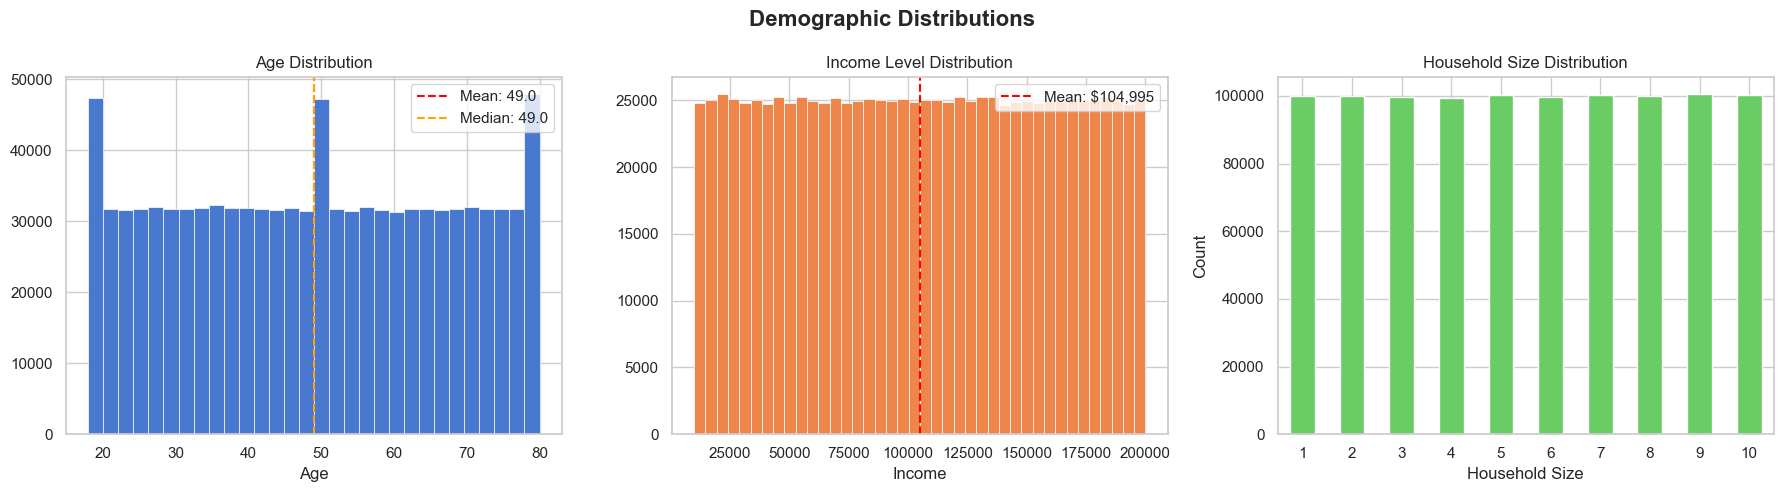

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Demographic Distributions', fontsize=16, fontweight='bold')

# Age distribution
axes[0].hist(df['age'], bins=30, color=COLORS[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', label=f'Median: {df["age"].median():.1f}')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].legend()

# Income distribution
axes[1].hist(df['income_level'], bins=40, color=COLORS[1], edgecolor='white', linewidth=0.5)
axes[1].axvline(df['income_level'].mean(), color='red', linestyle='--', label=f'Mean: ${df["income_level"].mean():,.0f}')
axes[1].set_title('Income Level Distribution')
axes[1].set_xlabel('Income')
axes[1].legend()

# Household size
df['household_size'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color=COLORS[2])
axes[2].set_title('Household Size Distribution')
axes[2].set_xlabel('Household Size')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4.2 Spending & Purchase Behavior

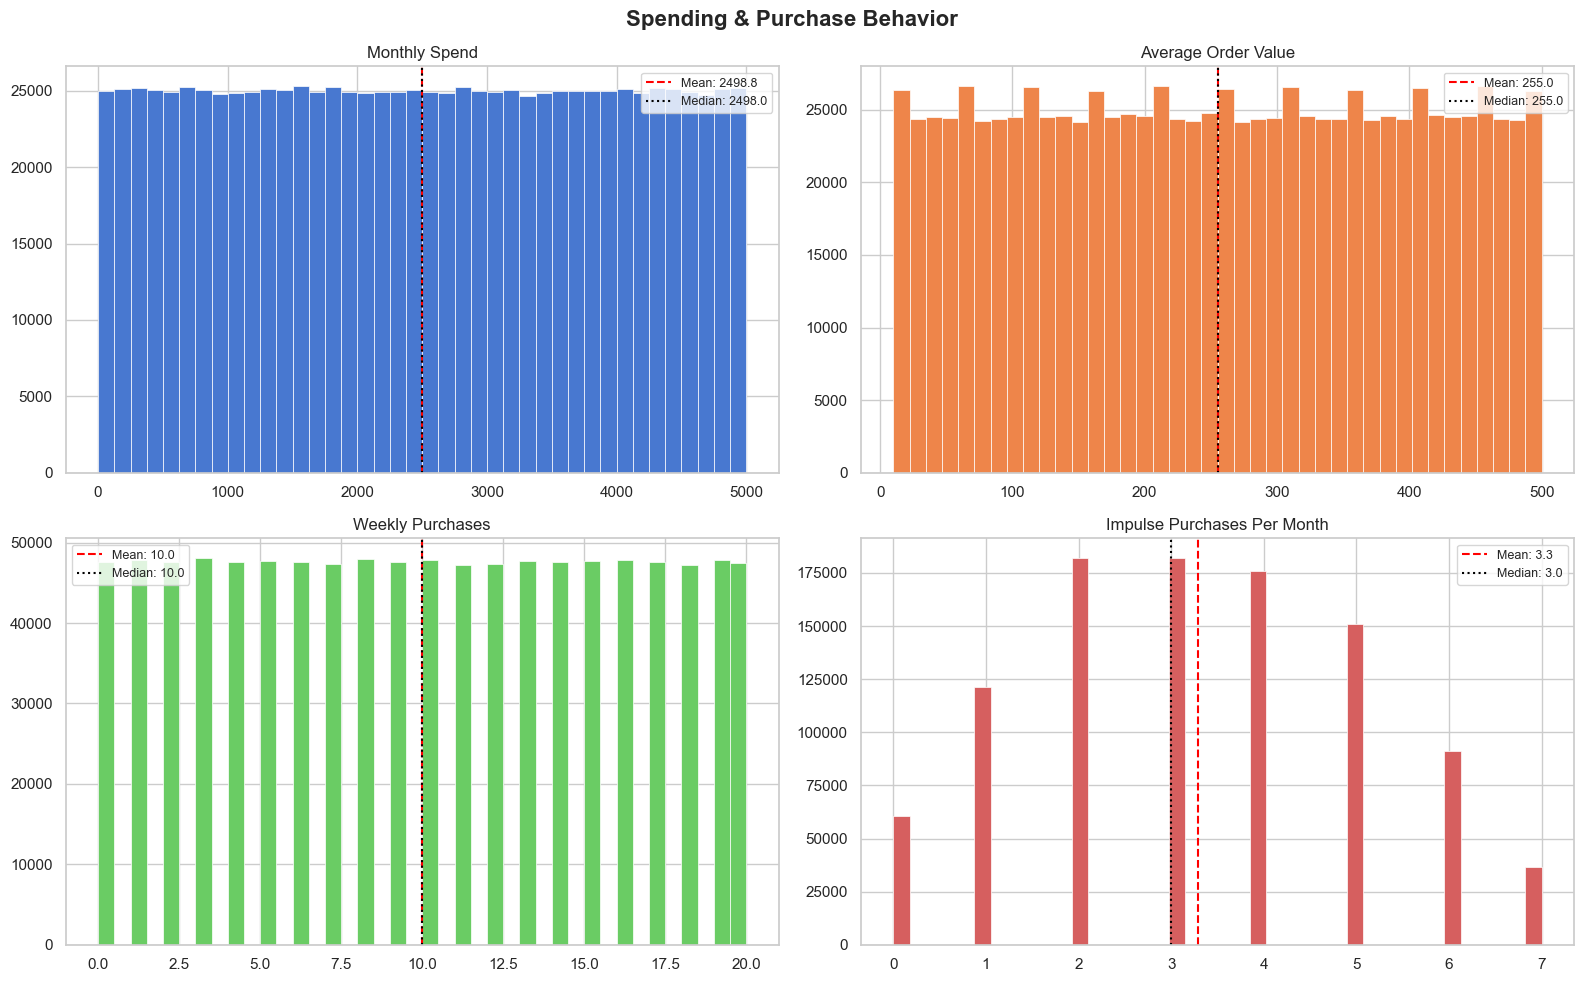

In [10]:
spend_cols = ['monthly_spend', 'average_order_value', 'weekly_purchases', 'impulse_purchases_per_month']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Spending & Purchase Behavior', fontsize=16, fontweight='bold')

for ax, col, color in zip(axes.flat, spend_cols, COLORS):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='black', linestyle=':', linewidth=1.5,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Binary & Categorical Features

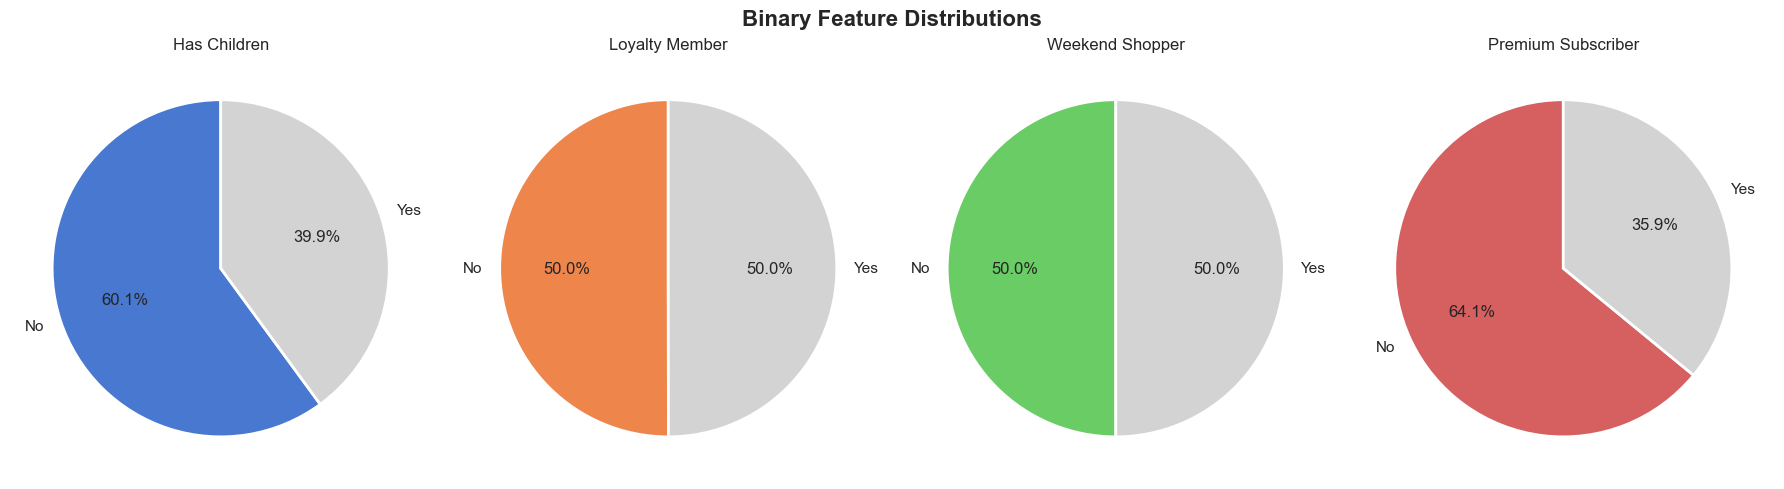

In [11]:
binary_cols = ['has_children', 'loyalty_program_member', 'weekend_shopper', 'premium_subscription']
labels = ['Has Children', 'Loyalty Member', 'Weekend Shopper', 'Premium Subscriber']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Binary Feature Distributions', fontsize=16, fontweight='bold')

for ax, col, label, color in zip(axes, binary_cols, labels, COLORS):
    counts = df[col].value_counts()
    ax.pie(counts, labels=['No', 'Yes'], autopct='%1.1f%%',
           colors=[color, 'lightgrey'], startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title(label)

plt.tight_layout()
plt.show()

### 4.4 Digital Engagement Metrics

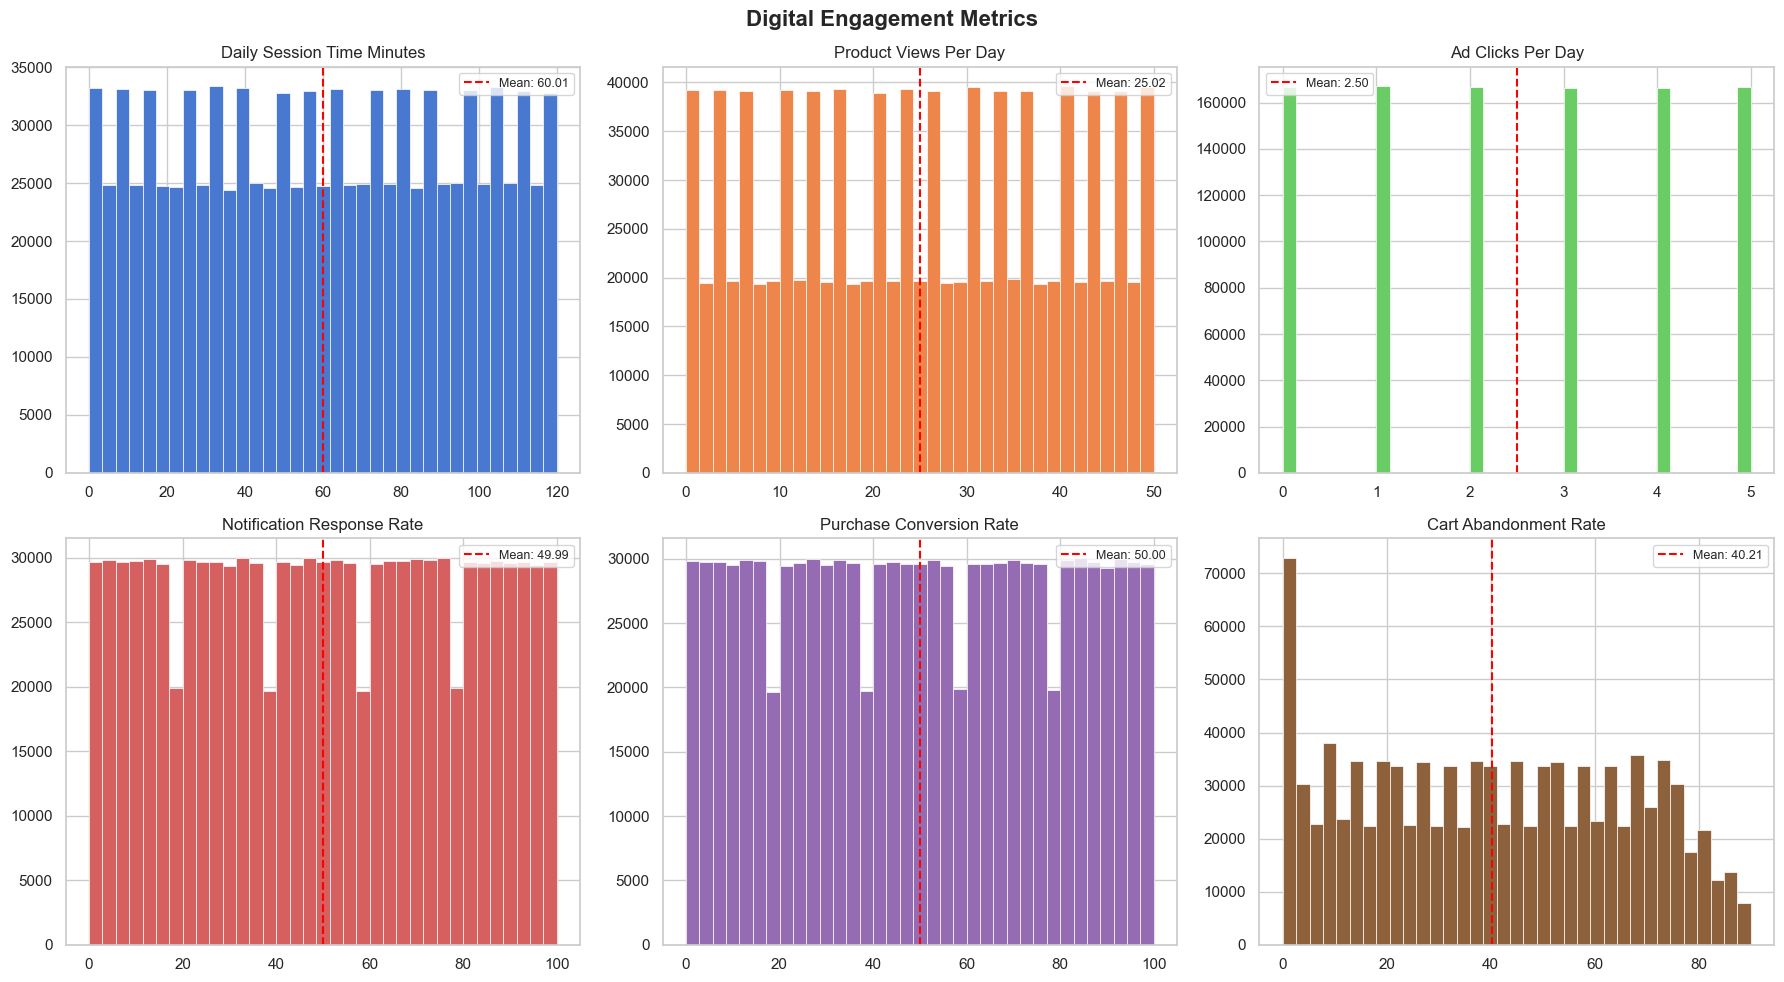

In [12]:
engagement_cols = [
    'daily_session_time_minutes', 'product_views_per_day',
    'ad_clicks_per_day', 'notification_response_rate',
    'purchase_conversion_rate', 'cart_abandonment_rate'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Digital Engagement Metrics', fontsize=16, fontweight='bold')

for ax, col, color in zip(axes.flat, engagement_cols, COLORS):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.2f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

### 5.1 Income vs Spending

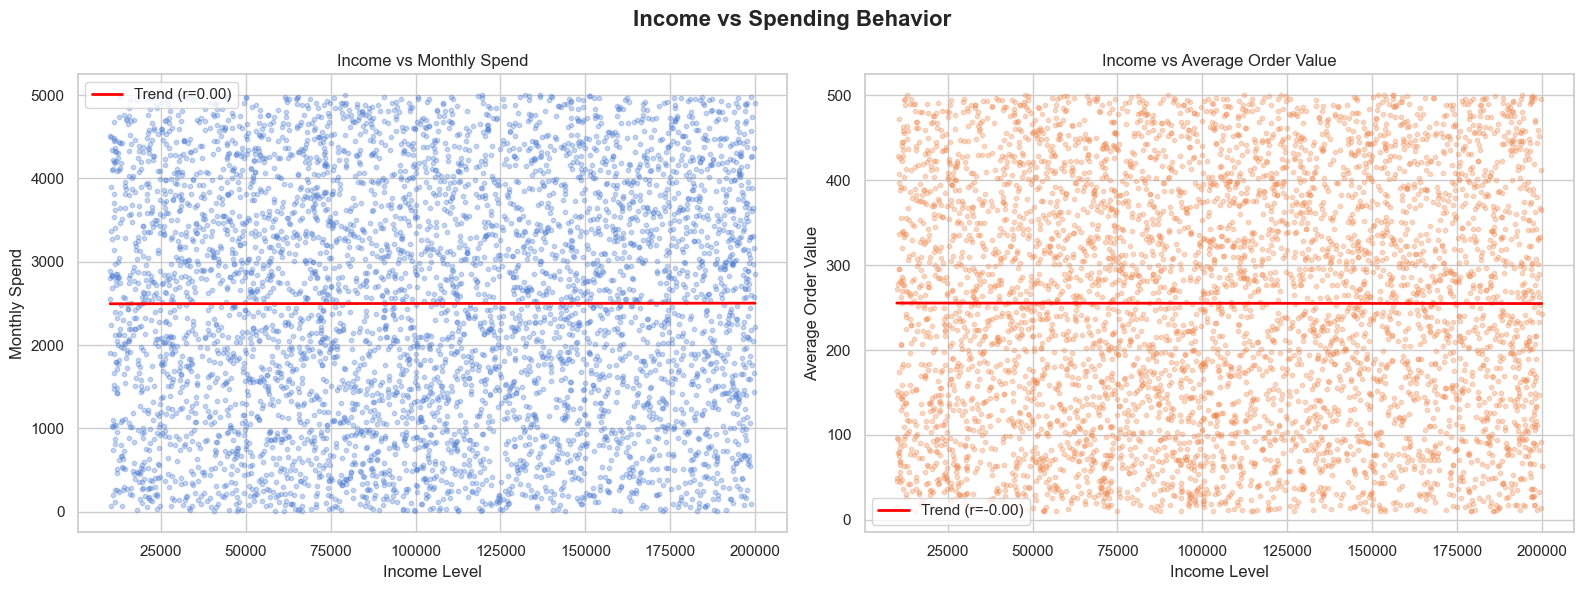

In [13]:
sample = df.sample(5000, random_state=42)  # plot sample for speed

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Income vs Spending Behavior', fontsize=16, fontweight='bold')

# Scatter: income vs monthly_spend
axes[0].scatter(sample['income_level'], sample['monthly_spend'],
                alpha=0.3, s=10, color=COLORS[0])
m, b = np.polyfit(df['income_level'], df['monthly_spend'], 1)
x_line = np.linspace(df['income_level'].min(), df['income_level'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (r={df[["income_level","monthly_spend"]].corr().iloc[0,1]:.2f})')
axes[0].set_xlabel('Income Level')
axes[0].set_ylabel('Monthly Spend')
axes[0].set_title('Income vs Monthly Spend')
axes[0].legend()

# Income vs avg order value
axes[1].scatter(sample['income_level'], sample['average_order_value'],
                alpha=0.3, s=10, color=COLORS[1])
m2, b2 = np.polyfit(df['income_level'], df['average_order_value'], 1)
axes[1].plot(x_line, m2 * x_line + b2, color='red', linewidth=2,
             label=f'Trend (r={df[["income_level","average_order_value"]].corr().iloc[0,1]:.2f})')
axes[1].set_xlabel('Income Level')
axes[1].set_ylabel('Average Order Value')
axes[1].set_title('Income vs Average Order Value')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Loyalty Members vs Non-Members

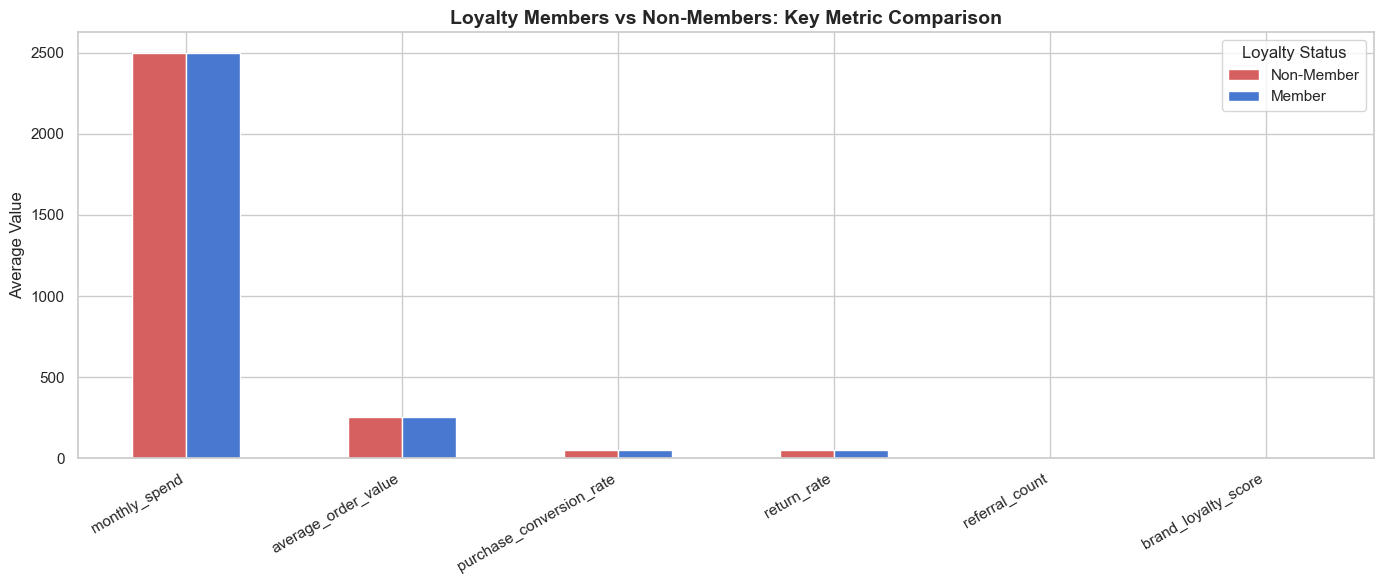


📊 Mean values by Loyalty Status:


,Non-Member,Member
monthly_spend,2498.16,2499.39
average_order_value,255.08,254.98
purchase_conversion_rate,49.97,50.03
return_rate,50.01,50.00
referral_count,5.01,5.00
brand_loyalty_score,5.00,5.00


In [14]:
compare_cols = ['monthly_spend', 'average_order_value', 'purchase_conversion_rate',
                'return_rate', 'referral_count', 'brand_loyalty_score']

loyalty_stats = df.groupby('loyalty_program_member')[compare_cols].mean()
loyalty_stats.index = ['Non-Member', 'Member']

loyalty_stats.T.plot(kind='bar', figsize=(14, 6), color=[COLORS[3], COLORS[0]])
plt.title('Loyalty Members vs Non-Members: Key Metric Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Average Value')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Loyalty Status')
plt.tight_layout()
plt.show()

print('\n📊 Mean values by Loyalty Status:')
display(loyalty_stats.T.round(2))

### 5.3 Age Group Analysis

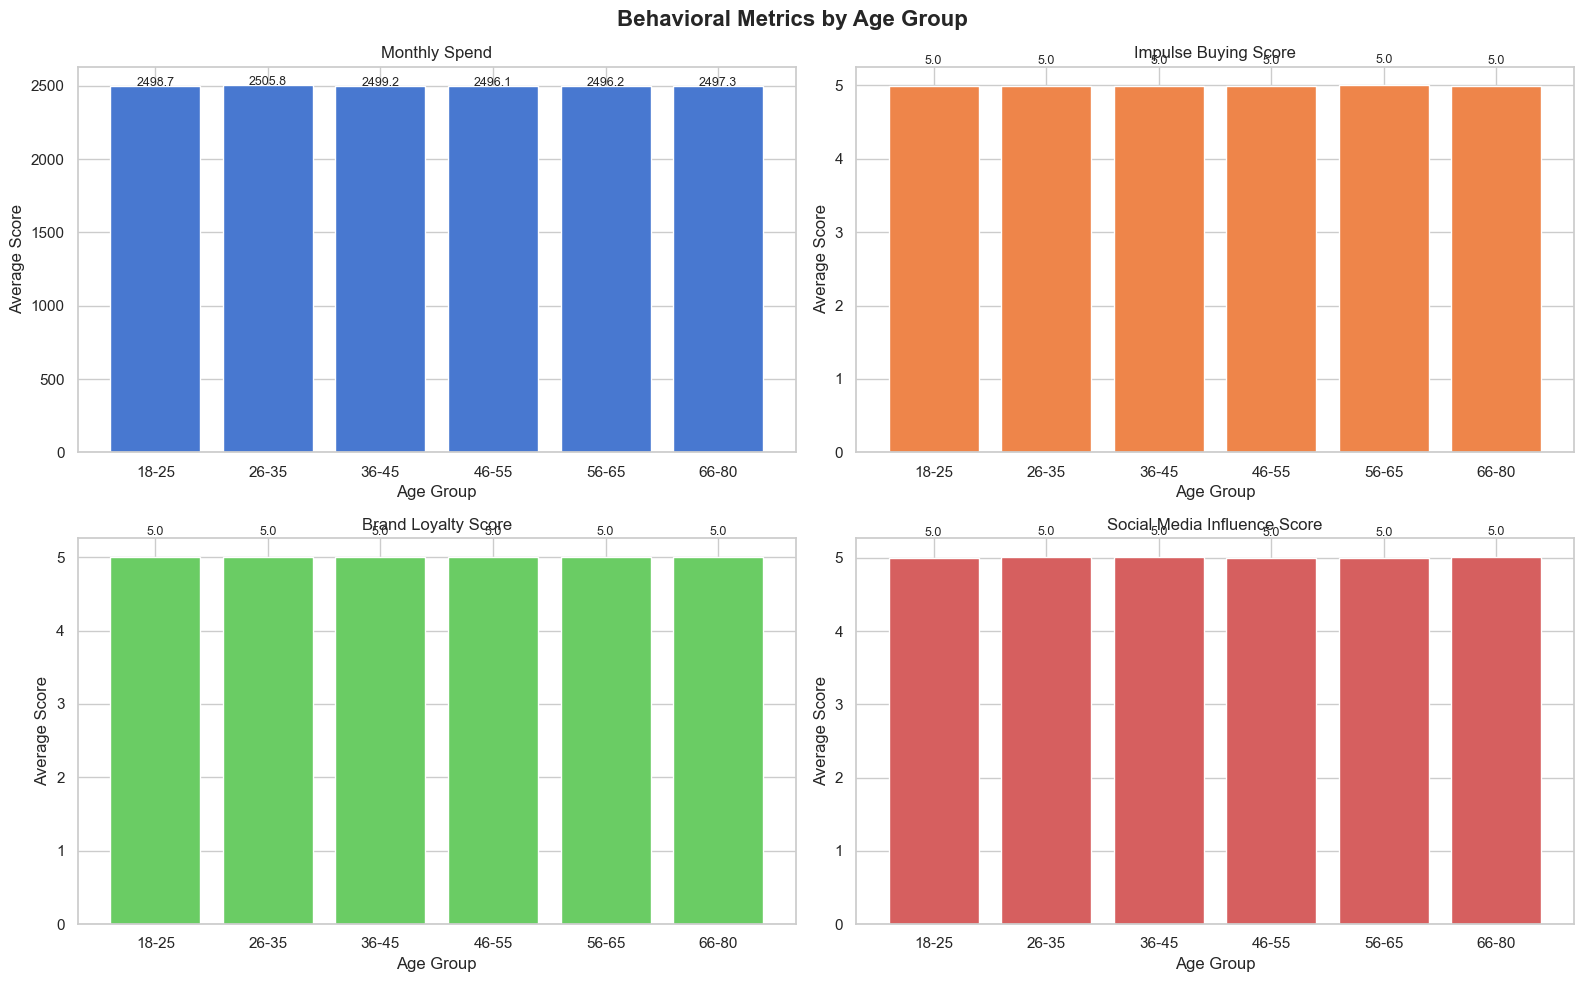

In [15]:
# Bin age into groups
df['age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65, 80],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66-80'])

age_metrics = df.groupby('age_group')[['monthly_spend', 'impulse_buying_score',
                                        'brand_loyalty_score', 'social_media_influence_score']].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Behavioral Metrics by Age Group', fontsize=16, fontweight='bold')

for ax, col, color in zip(axes.flat, age_metrics.columns, COLORS):
    bars = ax.bar(age_metrics.index, age_metrics[col], color=color, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Average Score')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.4 Premium Subscribers vs Free Users

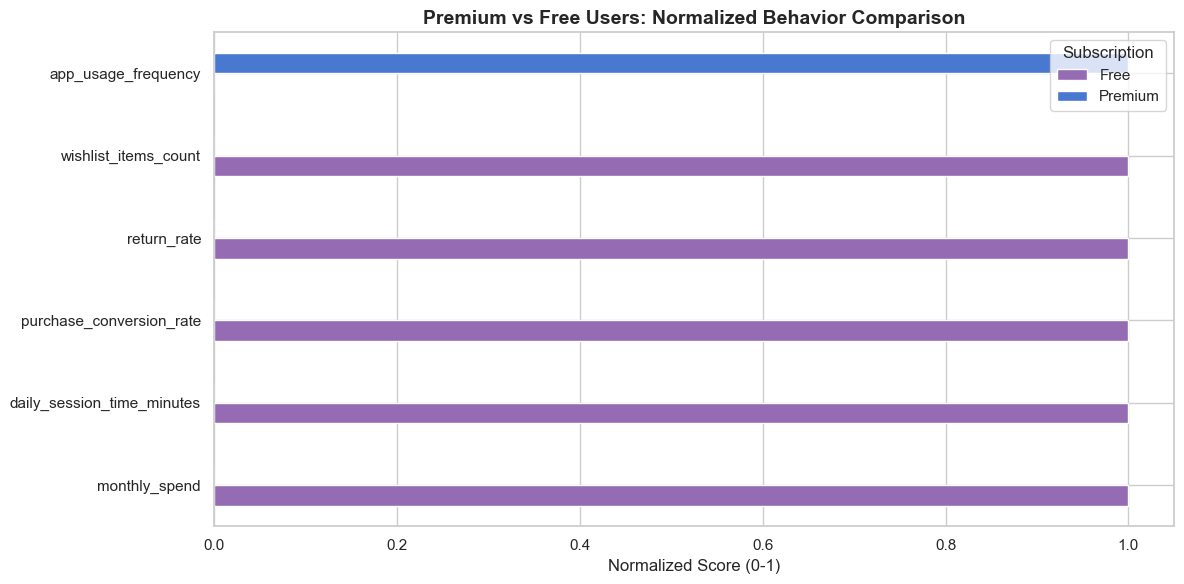


📊 Raw mean values:


,Free,Premium
monthly_spend,2499.73,2497.08
daily_session_time_minutes,60.02,60.00
purchase_conversion_rate,50.01,49.98
return_rate,50.01,50.00
wishlist_items_count,10.01,9.98
app_usage_frequency,3.50,3.50


In [16]:
premium_stats = df.groupby('premium_subscription')[[
    'monthly_spend', 'daily_session_time_minutes', 'purchase_conversion_rate',
    'return_rate', 'wishlist_items_count', 'app_usage_frequency'
]].mean()
premium_stats.index = ['Free', 'Premium']

# Normalized for radar-like bar comparison
normalized = (premium_stats - premium_stats.min()) / (premium_stats.max() - premium_stats.min())
normalized.T.plot(kind='barh', figsize=(12, 6), color=[COLORS[4], COLORS[0]])
plt.title('Premium vs Free Users: Normalized Behavior Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Score (0-1)')
plt.legend(title='Subscription')
plt.tight_layout()
plt.show()

print('\n📊 Raw mean values:')
display(premium_stats.T.round(2))

## 6. Correlation Analysis

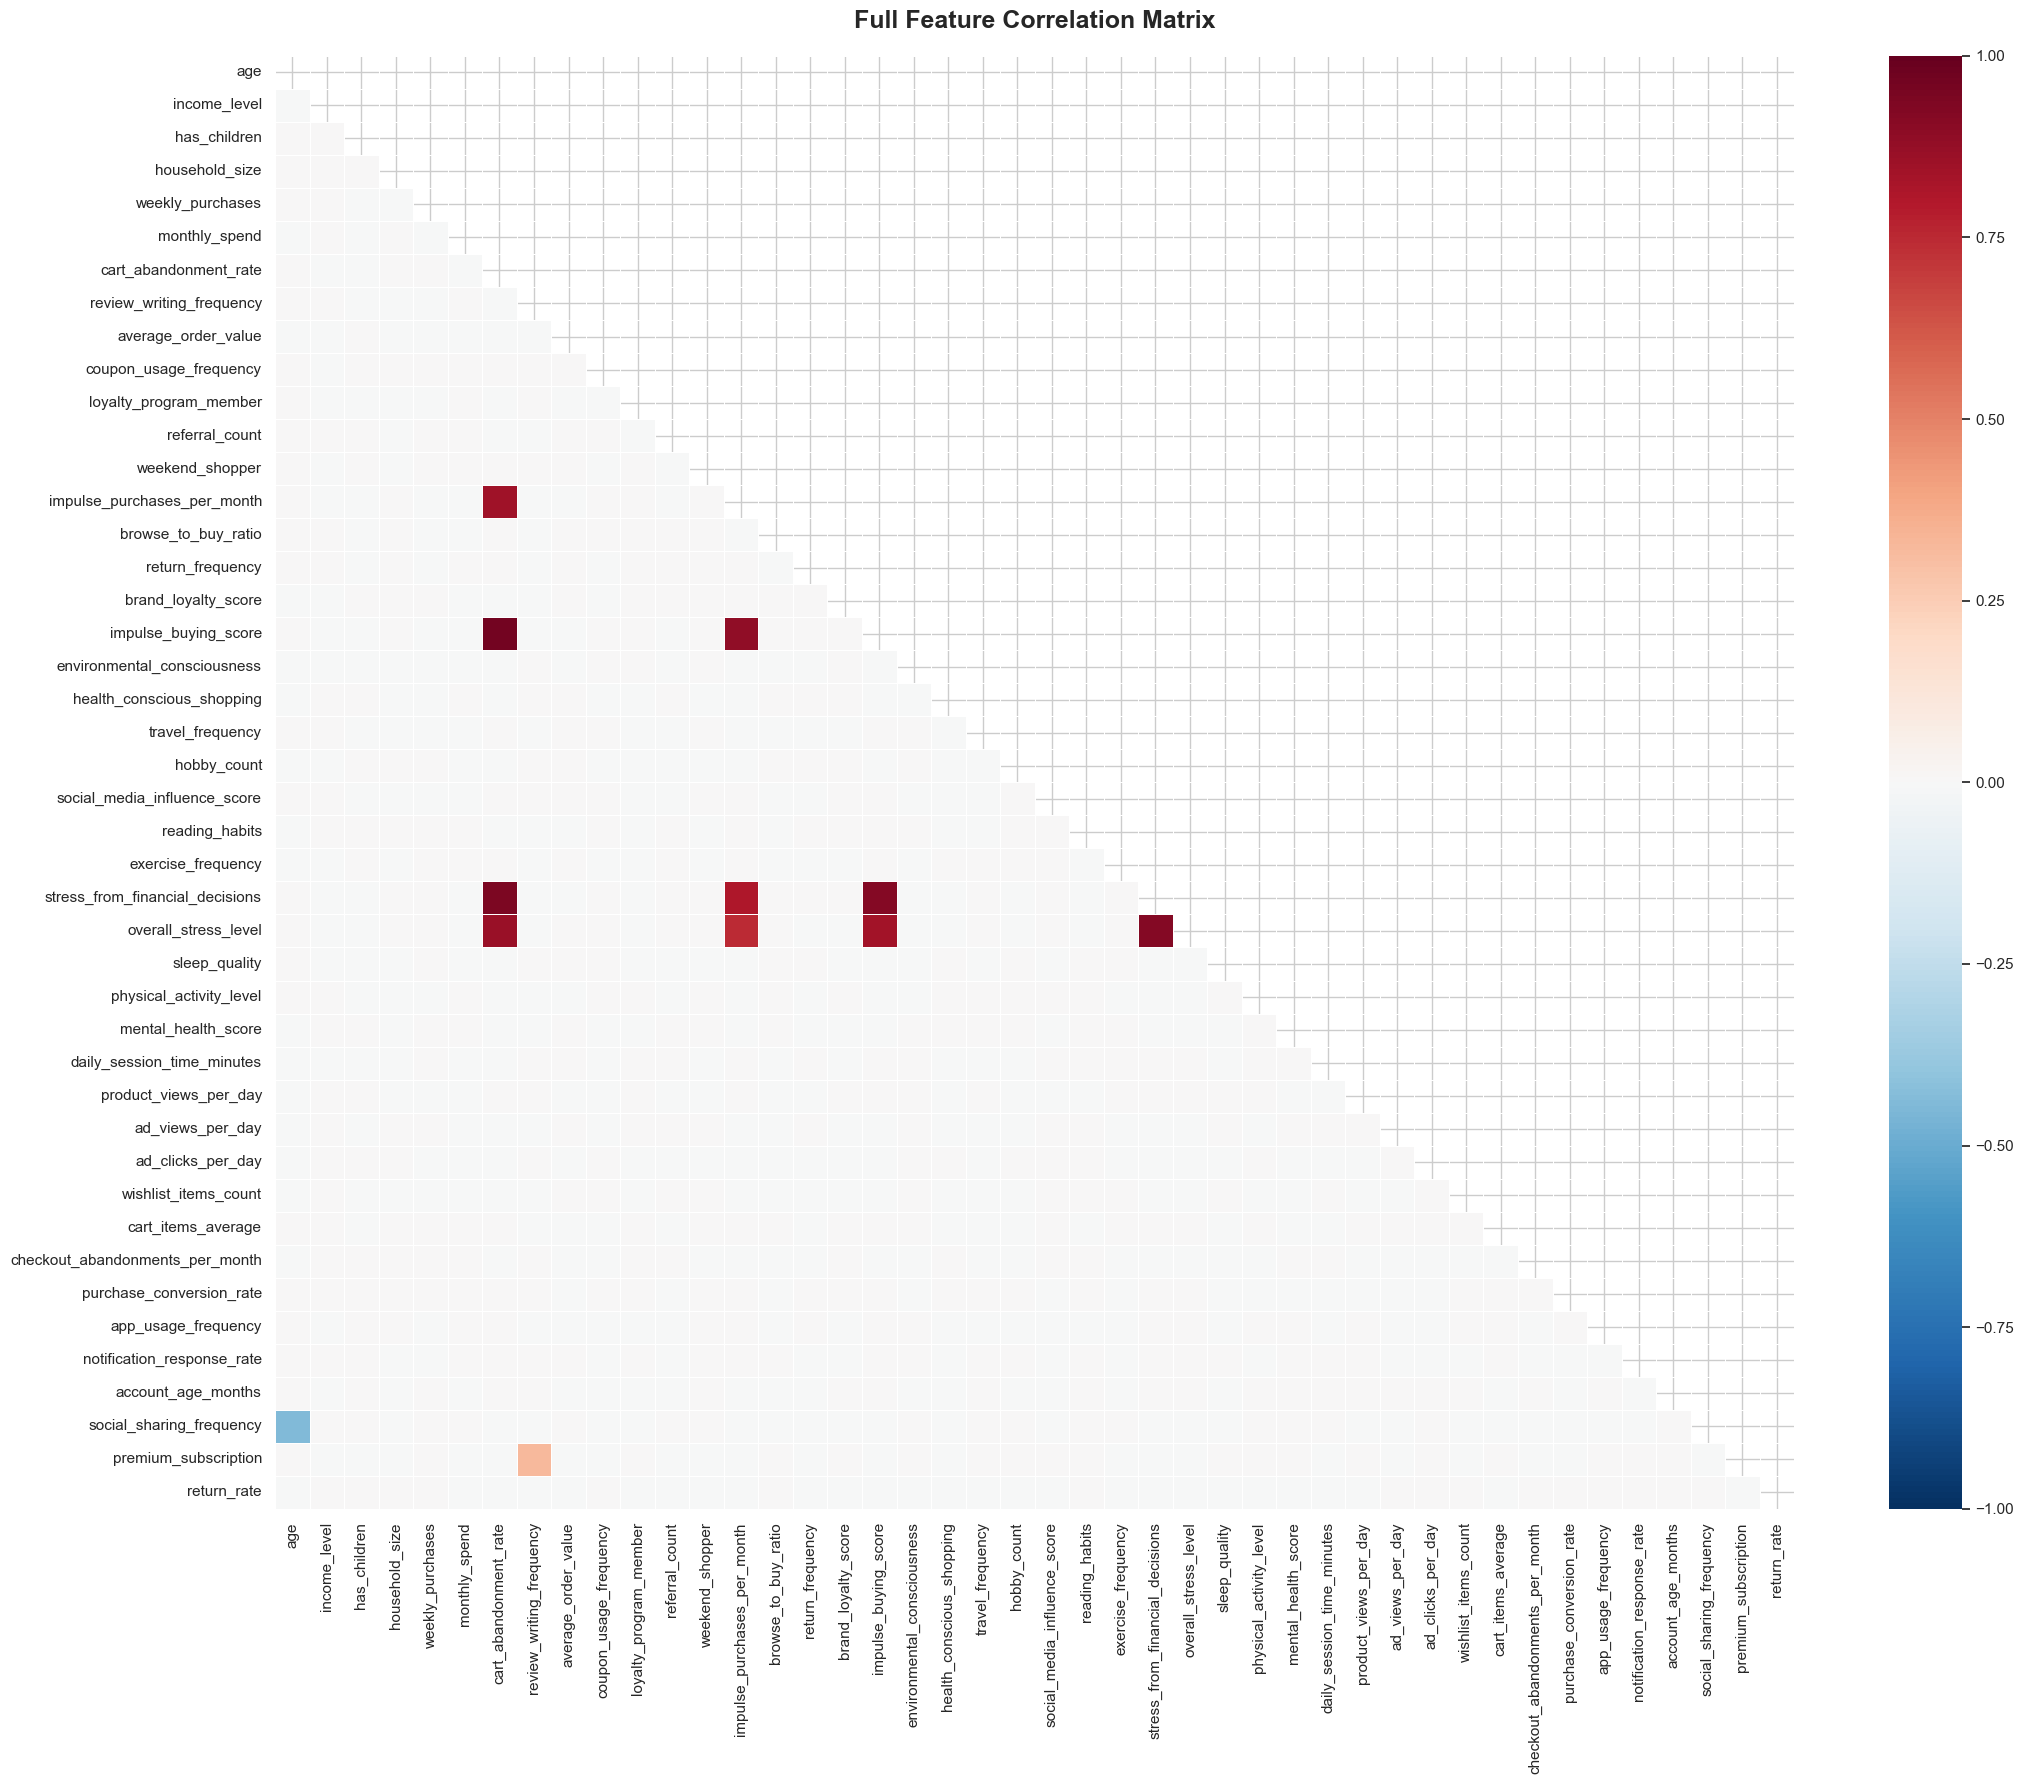

In [17]:
# Full correlation heatmap
num_cols = df.select_dtypes(include=np.number).drop(columns=['user_id']).columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Full Feature Correlation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

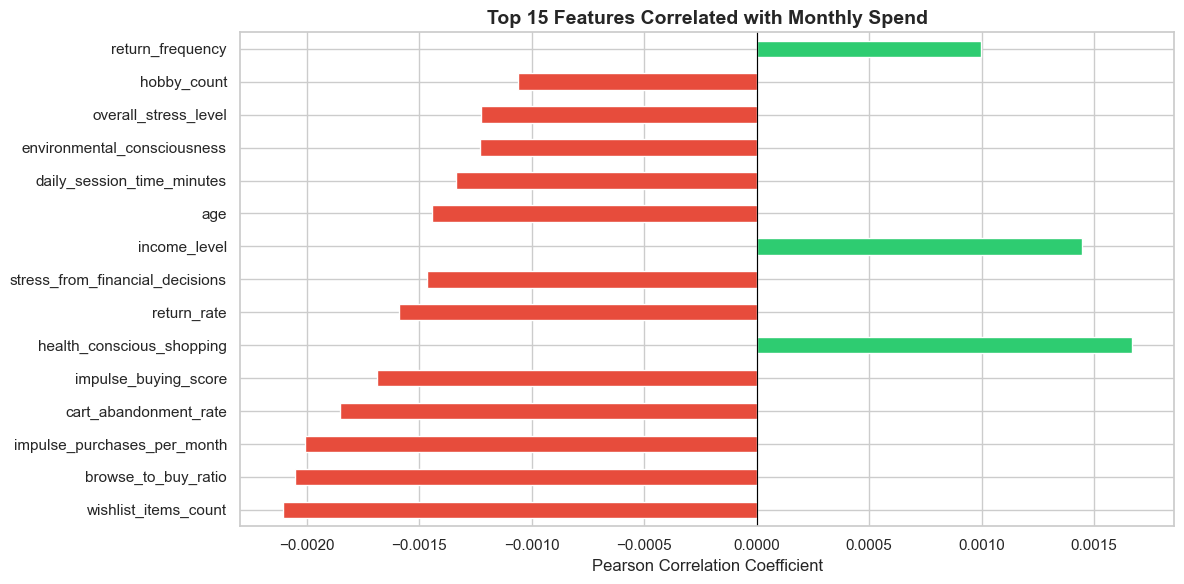

wishlist_items_count              -0.002
browse_to_buy_ratio               -0.002
impulse_purchases_per_month       -0.002
cart_abandonment_rate             -0.002
impulse_buying_score              -0.002
health_conscious_shopping          0.002
return_rate                       -0.002
stress_from_financial_decisions   -0.001
income_level                       0.001
age                               -0.001
daily_session_time_minutes        -0.001
environmental_consciousness       -0.001
overall_stress_level              -0.001
hobby_count                       -0.001
return_frequency                   0.001
Name: monthly_spend, dtype: float64


In [18]:
# Top correlations with monthly_spend
spend_corr = corr['monthly_spend'].drop('monthly_spend').sort_values(key=abs, ascending=False).head(15)

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in spend_corr]
spend_corr.plot(kind='barh', figsize=(12, 6), color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Correlated with Monthly Spend', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print(spend_corr.round(3))

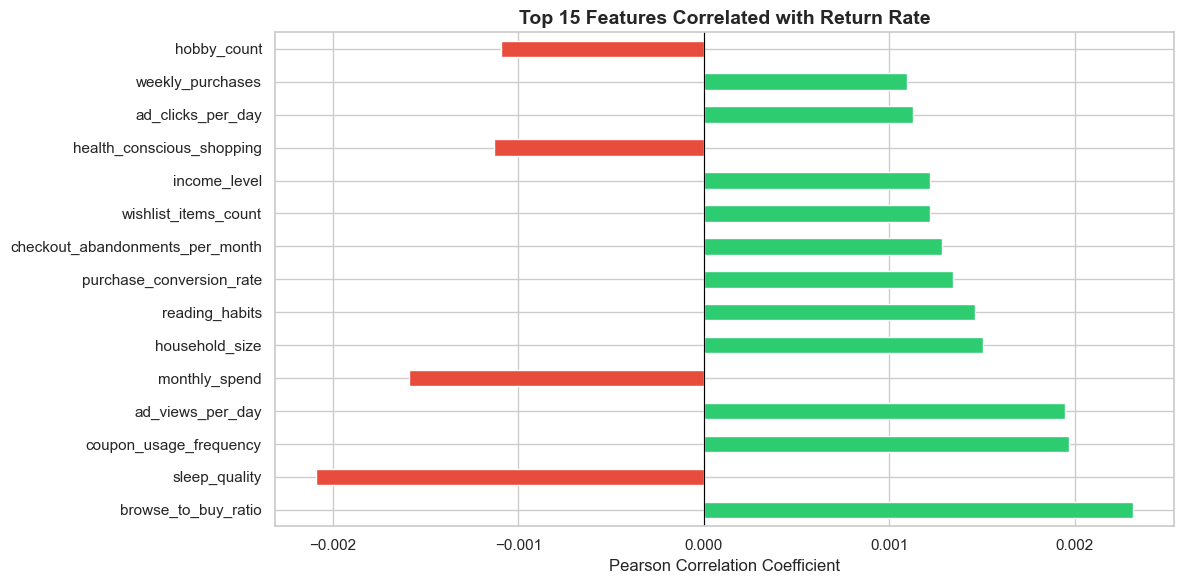

In [19]:
# Top correlations with return_rate
return_corr = corr['return_rate'].drop('return_rate').sort_values(key=abs, ascending=False).head(15)

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in return_corr]
return_corr.plot(kind='barh', figsize=(12, 6), color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Correlated with Return Rate', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

## 7. Behavioral Pattern Analysis

### 7.1 Outlier Detection (IQR Method)

In [20]:
key_cols = ['monthly_spend', 'average_order_value', 'return_rate',
            'impulse_purchases_per_month', 'referral_count', 'cart_abandonment_rate']

outlier_summary = []
for col in key_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'Lower Fence': lower, 'Upper Fence': upper,
                             'Outliers': n_outliers, 'Outlier %': round(n_outliers/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_summary).set_index('Column')
display(outlier_df.style.background_gradient(cmap='Oranges', subset=['Outlier %']))

,Q1,Q3,IQR,Lower Fence,Upper Fence,Outliers,Outlier %
Column,,,,,,,
monthly_spend,1249.000000,3750.000000,2501.000000,-2502.500000,7501.500000,0,0.000000
average_order_value,132.000000,378.000000,246.000000,-237.000000,747.000000,0,0.000000
return_rate,25.000000,75.000000,50.000000,-50.000000,150.000000,0,0.000000
impulse_purchases_per_month,2.000000,5.000000,3.000000,-2.500000,9.500000,0,0.000000
referral_count,2.000000,8.000000,6.000000,-7.000000,17.000000,0,0.000000
cart_abandonment_rate,18.000000,62.000000,44.000000,-48.000000,128.000000,0,0.000000


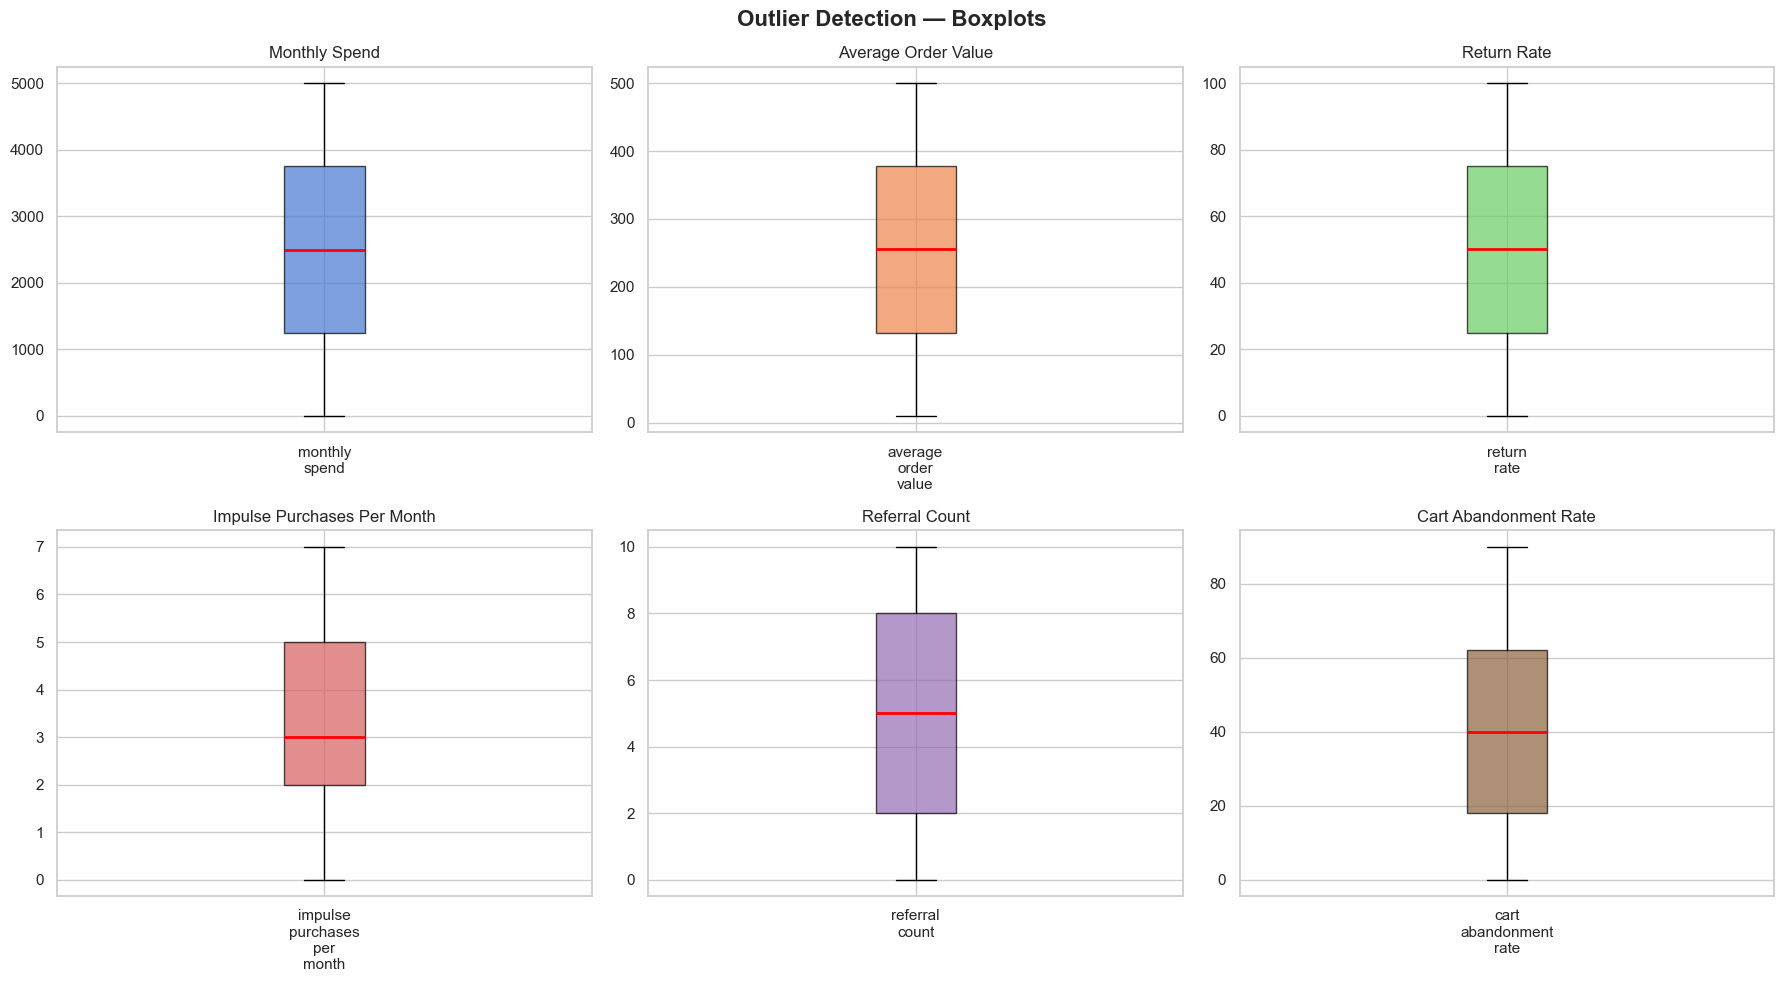

In [21]:
# Boxplots for key numerical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Outlier Detection — Boxplots', fontsize=16, fontweight='bold')

for ax, col, color in zip(axes.flat, key_cols, COLORS):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xticklabels([col.replace('_', '\n')])

plt.tight_layout()
plt.show()

### 7.2 Browse-to-Buy & Conversion Funnel

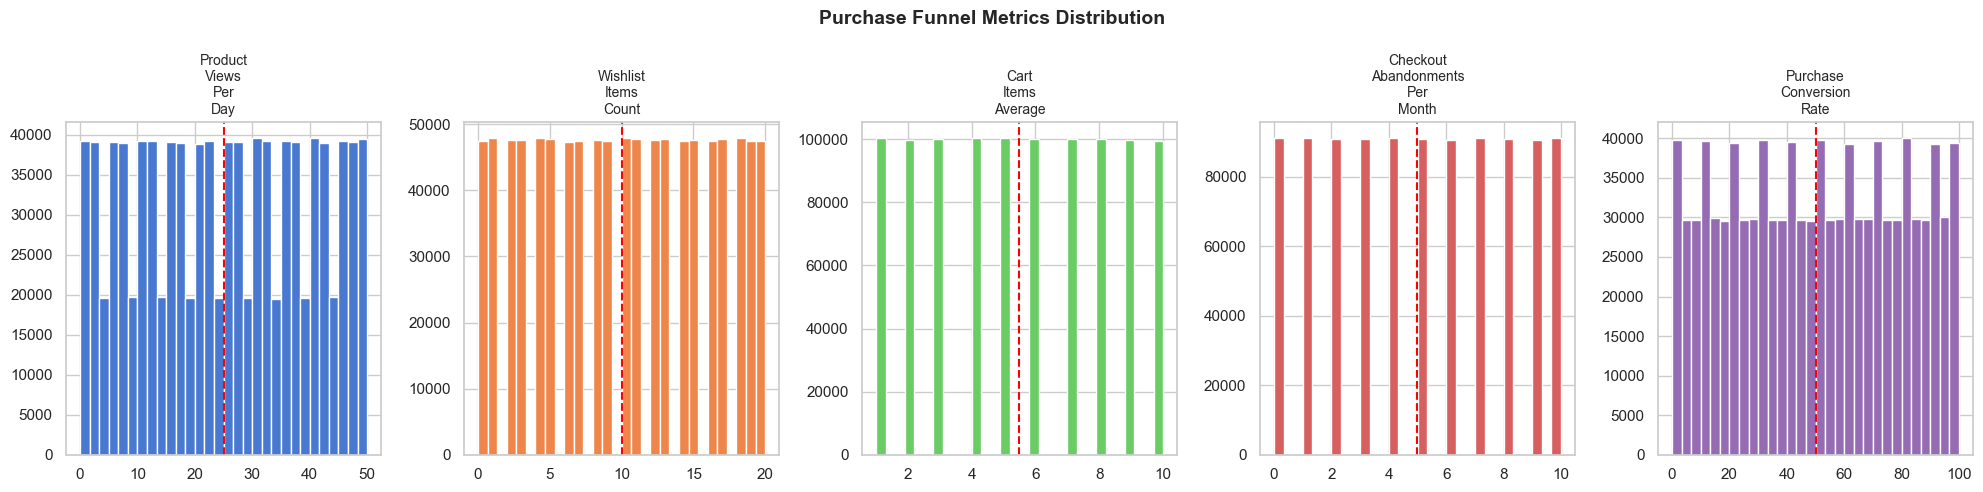

In [22]:
funnel_cols = ['product_views_per_day', 'wishlist_items_count', 'cart_items_average',
               'checkout_abandonments_per_month', 'purchase_conversion_rate']

fig, axes = plt.subplots(1, len(funnel_cols), figsize=(20, 5))
fig.suptitle('Purchase Funnel Metrics Distribution', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, funnel_cols, COLORS):
    ax.hist(df[col], bins=30, color=color, edgecolor='white')
    ax.set_title(col.replace('_', '\n').title(), fontsize=10)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

### 7.3 Coupon & Loyalty Behavior

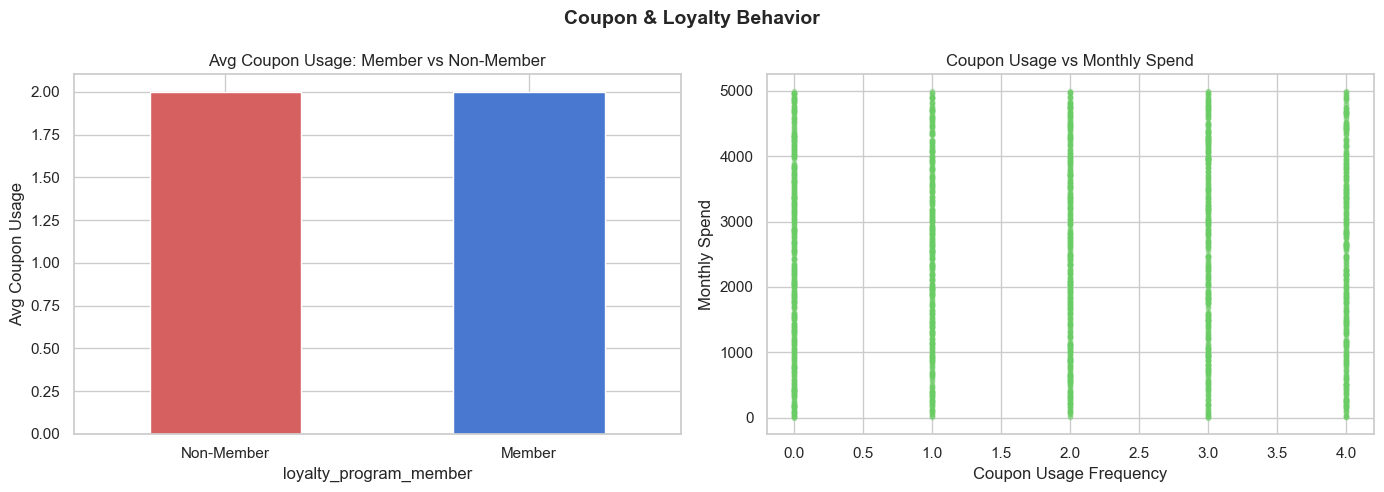

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Coupon & Loyalty Behavior', fontsize=14, fontweight='bold')

# Coupon usage by loyalty member
df.groupby('loyalty_program_member')['coupon_usage_frequency'].mean().plot(
    kind='bar', ax=axes[0], color=[COLORS[3], COLORS[0]])
axes[0].set_title('Avg Coupon Usage: Member vs Non-Member')
axes[0].set_xticklabels(['Non-Member', 'Member'], rotation=0)
axes[0].set_ylabel('Avg Coupon Usage')

# Coupon usage vs monthly spend (scatter)
sample = df.sample(3000, random_state=42)
axes[1].scatter(sample['coupon_usage_frequency'], sample['monthly_spend'],
                alpha=0.3, s=10, color=COLORS[2])
axes[1].set_xlabel('Coupon Usage Frequency')
axes[1].set_ylabel('Monthly Spend')
axes[1].set_title('Coupon Usage vs Monthly Spend')

plt.tight_layout()
plt.show()

## 8. Wellbeing vs Shopping Analysis
> Unique insight: How mental health & stress relate to buying behavior

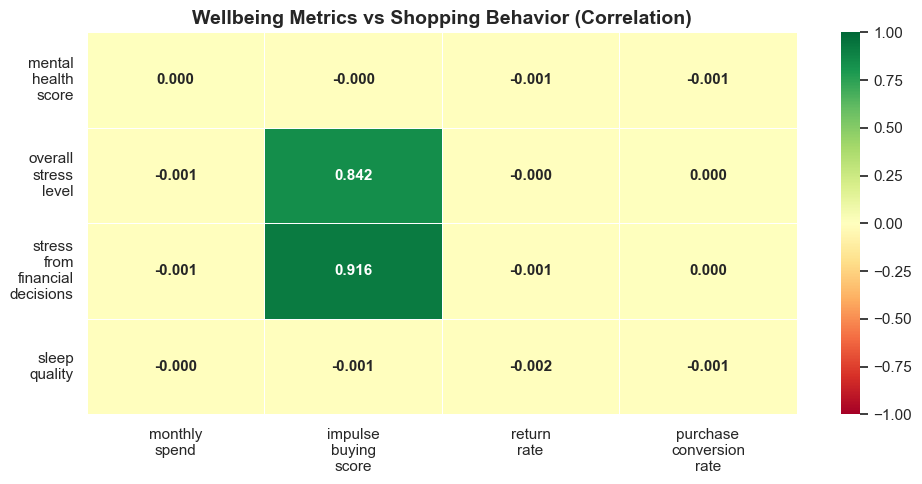

In [24]:
wellbeing_cols = ['mental_health_score', 'overall_stress_level',
                  'stress_from_financial_decisions', 'sleep_quality']
shopping_cols  = ['monthly_spend', 'impulse_buying_score', 'return_rate', 'purchase_conversion_rate']

wb_corr = df[wellbeing_cols + shopping_cols].corr().loc[wellbeing_cols, shopping_cols]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(wb_corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Wellbeing Metrics vs Shopping Behavior (Correlation)', fontsize=14, fontweight='bold')
ax.set_xticklabels([c.replace('_', '\n') for c in shopping_cols], rotation=0)
ax.set_yticklabels([c.replace('_', '\n') for c in wellbeing_cols], rotation=0)
plt.tight_layout()
plt.show()

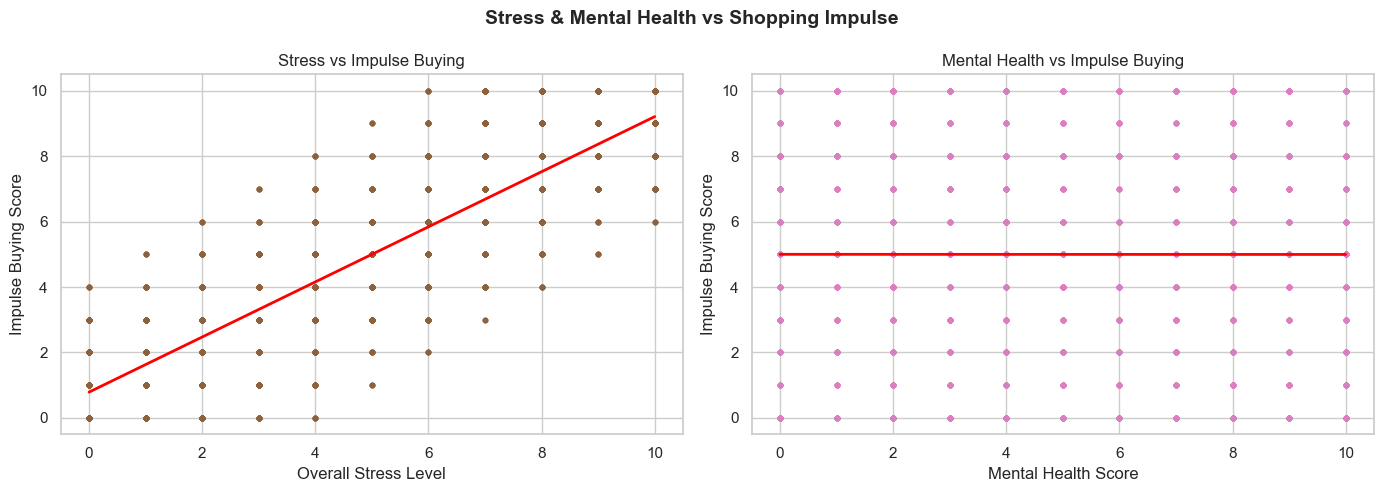

In [25]:
# Stress vs Impulse Buying
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stress & Mental Health vs Shopping Impulse', fontsize=14, fontweight='bold')

sample = df.sample(5000, random_state=42)

axes[0].scatter(sample['overall_stress_level'], sample['impulse_buying_score'],
                alpha=0.2, s=10, color=COLORS[5])
m, b = np.polyfit(df['overall_stress_level'], df['impulse_buying_score'], 1)
x = np.linspace(0, 10, 100)
axes[0].plot(x, m*x+b, color='red', linewidth=2)
axes[0].set_xlabel('Overall Stress Level')
axes[0].set_ylabel('Impulse Buying Score')
axes[0].set_title('Stress vs Impulse Buying')

axes[1].scatter(sample['mental_health_score'], sample['impulse_buying_score'],
                alpha=0.2, s=10, color=COLORS[6])
m2, b2 = np.polyfit(df['mental_health_score'], df['impulse_buying_score'], 1)
axes[1].plot(x, m2*x+b2, color='red', linewidth=2)
axes[1].set_xlabel('Mental Health Score')
axes[1].set_ylabel('Impulse Buying Score')
axes[1].set_title('Mental Health vs Impulse Buying')

plt.tight_layout()
plt.show()

## 9. Key Insights Summary

In [26]:
print('=' * 65)
print('         📊 EDA KEY INSIGHTS SUMMARY')
print('=' * 65)

# Demographics
print('\n👥 DEMOGRAPHICS')
print(f'  • Age range      : {df["age"].min()} – {df["age"].max()} | Mean: {df["age"].mean():.1f}')
print(f'  • Income range   : ${df["income_level"].min():,.0f} – ${df["income_level"].max():,.0f}')
print(f'  • Has children   : {df["has_children"].mean()*100:.1f}% of users')

# Spending
print('\n💰 SPENDING BEHAVIOR')
print(f'  • Avg monthly spend      : ${df["monthly_spend"].mean():,.2f}')
print(f'  • Avg order value        : ${df["average_order_value"].mean():,.2f}')
print(f'  • Avg weekly purchases   : {df["weekly_purchases"].mean():.1f}')
print(f'  • Cart abandonment rate  : {df["cart_abandonment_rate"].mean():.1f}%')

# Loyalty & Premium
print('\n🏆 LOYALTY & SUBSCRIPTIONS')
print(f'  • Loyalty members     : {df["loyalty_program_member"].mean()*100:.1f}%')
print(f'  • Premium subscribers : {df["premium_subscription"].mean()*100:.1f}%')
print(f'  • Weekend shoppers    : {df["weekend_shopper"].mean()*100:.1f}%')

# Engagement
print('\n📱 DIGITAL ENGAGEMENT')
print(f'  • Avg daily session    : {df["daily_session_time_minutes"].mean():.1f} min')
print(f'  • Avg product views/day: {df["product_views_per_day"].mean():.1f}')
print(f'  • Avg conversion rate  : {df["purchase_conversion_rate"].mean():.1f}%')
print(f'  • Avg return rate      : {df["return_rate"].mean():.1f}%')

# Wellbeing
print('\n🧠 WELLBEING')
print(f'  • Avg mental health score     : {df["mental_health_score"].mean():.2f}/10')
print(f'  • Avg overall stress level    : {df["overall_stress_level"].mean():.2f}/10')
print(f'  • Avg sleep quality           : {df["sleep_quality"].mean():.2f}/9')
print(f'  • Financial stress avg        : {df["stress_from_financial_decisions"].mean():.2f}/10')

# Top correlations
top_spend_corr = corr['monthly_spend'].drop('monthly_spend').sort_values(key=abs, ascending=False).head(3)
print('\n🔗 TOP CORRELATIONS WITH MONTHLY SPEND')
for feat, val in top_spend_corr.items():
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'  • {feat:<35} : {val:.3f} ({direction})')

print('\n' + '=' * 65)
print('✅ EDA Complete — Proceed to Phase 2: Preprocessing')
print('=' * 65)

         📊 EDA KEY INSIGHTS SUMMARY

👥 DEMOGRAPHICS
  • Age range      : 18 – 80 | Mean: 49.0
  • Income range   : $10,000 – $200,000
  • Has children   : 39.9% of users

💰 SPENDING BEHAVIOR
  • Avg monthly spend      : $2,498.78
  • Avg order value        : $255.03
  • Avg weekly purchases   : 10.0
  • Cart abandonment rate  : 40.2%

🏆 LOYALTY & SUBSCRIPTIONS
  • Loyalty members     : 50.0%
  • Premium subscribers : 35.9%
  • Weekend shoppers    : 50.0%

📱 DIGITAL ENGAGEMENT
  • Avg daily session    : 60.0 min
  • Avg product views/day: 25.0
  • Avg conversion rate  : 50.0%
  • Avg return rate      : 50.0%

🧠 WELLBEING
  • Avg mental health score     : 5.00/10
  • Avg overall stress level    : 5.00/10
  • Avg sleep quality           : 6.50/9
  • Financial stress avg        : 5.00/10

🔗 TOP CORRELATIONS WITH MONTHLY SPEND
  • wishlist_items_count                : -0.002 (↓ negative)
  • browse_to_buy_ratio                 : -0.002 (↓ negative)
  • impulse_purchases_per_month         : 

---
## ✅ Next Steps

| Phase | Notebook | Description |
|-------|----------|-------------|
| Phase 2 | `02_Preprocessing.ipynb` | Feature engineering, encoding, scaling |
| Phase 3 | `03_Segmentation.ipynb` | KMeans clustering, PCA, buyer personas |
| Phase 4 | `04_ML_Models.ipynb` | Prediction models + SHAP explainability |